# Battery-siting ranking vs. |nodal congestion premium| ranking (2025-hourly)

**What this does**
1. Ranks **every** battery location in `grid_siting_scores_20260629_155333.csv`
   by its locational value `dV_proxy_eur_per_year` (rank 1 = best site).
2. Takes the 10 German nodes in `nodal_vs_siting_comparison_2025.csv` and ranks
   them by **absolute congestion premium** |LMP − zonal mean| (rank 1 = most
   locationally-divergent node in the PyPSA-Eur 2025-hourly model).
3. Brings the fine siting ranking up to the 10 nodes (each cell → nearest node)
   and compares the two orderings.

Note: `nodal_vs_siting_comparison_2025.csv` is the **PyPSA-Eur 2025-hourly** run
(full-year hourly, 10 DE nodes), not SciGRID.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from scipy.stats import spearmanr, kendalltau
plt.rcParams['figure.dpi']=110; plt.rcParams['font.size']=10
SITE = "../battery_siting_score/out/grid_siting_scores_20260629_155333.csv"
NODE = "nodal_vs_siting_comparison_2025.csv"
SCORE_COL = "dV_proxy_eur_per_year"     # locational value used to rank battery sites

## 1. Relative ranking of ALL battery locations (fine grid)

In [2]:
sit = pd.read_csv(SITE)
sit = sit.sort_values(SCORE_COL, ascending=False).reset_index(drop=True)
sit['site_rank']       = np.arange(1, len(sit)+1)          # 1 = best
sit['site_percentile'] = sit[SCORE_COL].rank(pct=True)     # 1.0 = best
sit.to_csv("battery_location_ranking_full.csv", index=False)
print(f"ranked {len(sit)} battery locations -> battery_location_ranking_full.csv")
sit[['site_rank','lon','lat','bus_idx',SCORE_COL,'site_percentile']].head(10)

ranked 4593 battery locations -> battery_location_ranking_full.csv


,site_rank,lon,lat,bus_idx,dV_proxy_eur_per_year,site_percentile
0,1,11.0,51.2,383,1.623798e+07,0.999565
1,2,10.9,51.2,383,1.623798e+07,0.999565
2,3,11.0,51.1,383,1.623798e+07,0.999565
3,4,11.1,51.1,383,1.623798e+07,0.999565
4,5,11.2,51.0,383,1.623798e+07,0.999565
5,6,13.2,51.3,325,1.601882e+07,0.995319
6,7,13.0,51.3,325,1.601882e+07,0.995319
7,8,13.3,51.3,325,1.601882e+07,0.995319
8,9,13.1,51.3,325,1.601882e+07,0.995319
9,10,13.4,51.3,325,1.601882e+07,0.995319


## 2. Rank the 10 nodes by absolute congestion premium

In [3]:
nod = pd.read_csv(NODE)
nod['abs_congestion'] = nod['congestion_premium'].abs()
nod['congestion_rank'] = nod['abs_congestion'].rank(ascending=False, method='min').astype(int)
nod.sort_values('congestion_rank')[['bus','congestion_premium','abs_congestion','congestion_rank']]

,bus,congestion_premium,abs_congestion,congestion_rank
4,DE0 4AC,1.267,1.267,1
0,DE0 0AC,0.920,0.920,2
9,DE0 9AC,-0.696,0.696,3
5,DE0 5AC,-0.456,0.456,4
3,DE0 3AC,-0.434,0.434,5
1,DE0 1AC,-0.395,0.395,6
6,DE0 6AC,-0.271,0.271,7
2,DE0 2AC,-0.167,0.167,8
7,DE0 7AC,0.167,0.167,8
8,DE0 8AC,0.067,0.067,10


## 3. Bring the fine siting ranking up to the 10 nodes

Each fine cell is assigned to its nearest node (by lon/lat). The node's siting
strength is the **mean site-percentile** of its cells (equivalently reflected by
`sit_dV`); nodes are then ranked 1..10 by that.

In [4]:
nx, ny = nod['x'].values, nod['y'].values
sit['node'] = [nod['bus'].values[((nx-lo)**2+(ny-la)**2).argmin()]
               for lo,la in zip(sit['lon'], sit['lat'])]
node_site = (sit.groupby('node')
                .agg(mean_site_percentile=('site_percentile','mean'),
                     mean_dV=(SCORE_COL,'mean'),
                     n_cells=('site_rank','size')).reset_index())
node_site['siting_rank'] = node_site['mean_site_percentile'].rank(ascending=False, method='min').astype(int)
cmp = nod.merge(node_site, left_on='bus', right_on='node')
cmp['rank_gap'] = cmp['siting_rank'] - cmp['congestion_rank']
cols=['bus','mean_dV','mean_site_percentile','siting_rank','abs_congestion','congestion_rank','rank_gap']
cmp[cols].sort_values('siting_rank').round(3)

,bus,mean_dV,mean_site_percentile,siting_rank,abs_congestion,congestion_rank,rank_gap
6,DE0 6AC,1.242793e+07,0.835,1,0.271,7,-6
8,DE0 8AC,1.025600e+07,0.696,2,0.067,10,-8
1,DE0 1AC,9.040687e+06,0.617,3,0.395,6,-3
9,DE0 9AC,7.391054e+06,0.521,4,0.696,3,1
3,DE0 3AC,7.412779e+06,0.508,5,0.434,5,0
7,DE0 7AC,6.938742e+06,0.462,6,0.167,8,-2
5,DE0 5AC,6.391192e+06,0.434,7,0.456,4,3
4,DE0 4AC,5.407144e+06,0.351,8,1.267,1,7
2,DE0 2AC,5.081173e+06,0.331,9,0.167,8,1
0,DE0 0AC,3.693170e+06,0.213,10,0.920,2,8


## 4. Do the two orderings agree?

In [5]:
rho, p_s = spearmanr(cmp['siting_rank'], cmp['congestion_rank'])
tau, p_k = kendalltau(cmp['siting_rank'], cmp['congestion_rank'])
# equivalently on the underlying values (higher siting value vs higher |congestion|)
rho_v,_ = spearmanr(cmp['mean_dV'], cmp['abs_congestion'])
print(f"Spearman (siting rank vs |congestion| rank): rho = {rho:+.3f}  (p={p_s:.3f})")
print(f"Kendall  tau                               : tau = {tau:+.3f}  (p={p_k:.3f})")
print(f"Spearman on values (mean_dV vs |congestion|): rho = {rho_v:+.3f}")

Spearman (siting rank vs |congestion| rank): rho = -0.450  (p=0.192)
Kendall  tau                               : tau = -0.360  (p=0.151)
Spearman on values (mean_dV vs |congestion|): rho = -0.474


### 4a. Rank–rank slope chart

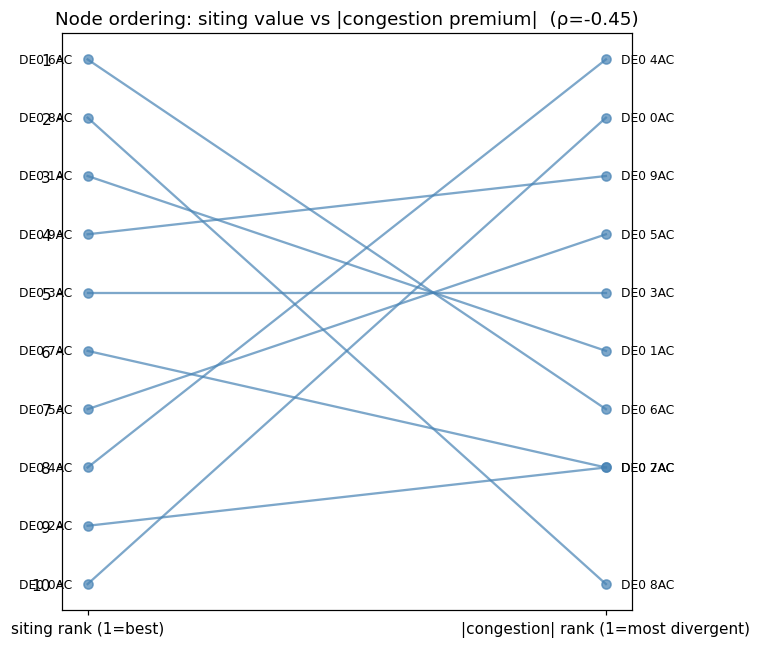

In [6]:
order = cmp.sort_values('siting_rank')
plt.figure(figsize=(7,6))
for _,r in order.iterrows():
    plt.plot([0,1],[r['siting_rank'],r['congestion_rank']],'-o',color='steelblue',alpha=.7)
    plt.text(-0.03,r['siting_rank'],r['bus'],ha='right',va='center',fontsize=8)
    plt.text(1.03,r['congestion_rank'],r['bus'],ha='left',va='center',fontsize=8)
plt.gca().invert_yaxis()
plt.xticks([0,1],['siting rank (1=best)','|congestion| rank (1=most divergent)'])
plt.yticks(range(1,11)); plt.title(f'Node ordering: siting value vs |congestion premium|  (ρ={rho:+.2f})')
plt.tight_layout(); plt.show()

### 4b. Scatter of the two ranks

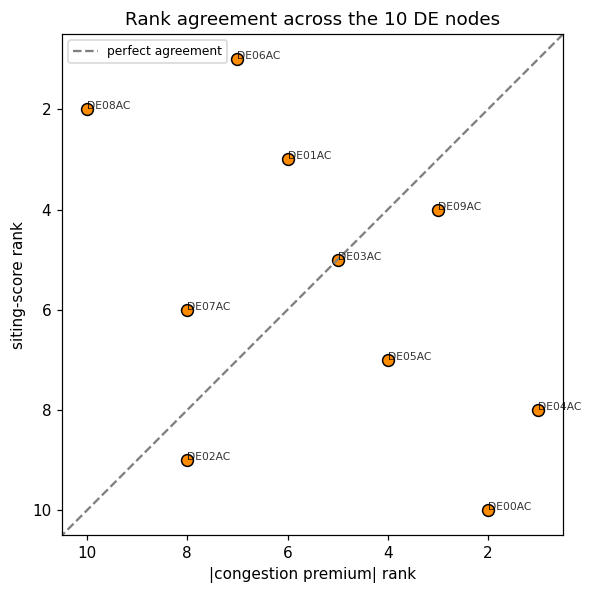

In [7]:
plt.figure(figsize=(5.5,5.5))
plt.scatter(cmp['congestion_rank'],cmp['siting_rank'],s=60,c='darkorange',edgecolor='k')
for _,r in cmp.iterrows():
    plt.annotate(r['bus'].replace(' ',''),(r['congestion_rank'],r['siting_rank']),fontsize=7,alpha=.8)
lims=[0.5,10.5]; plt.plot(lims,lims,'--',color='grey',label='perfect agreement')
plt.xlim(lims); plt.ylim(lims); plt.gca().invert_yaxis(); plt.gca().invert_xaxis()
plt.xlabel('|congestion premium| rank'); plt.ylabel('siting-score rank'); plt.legend(fontsize=8)
plt.title('Rank agreement across the 10 DE nodes'); plt.tight_layout(); plt.show()

## 5. Save the node comparison table

In [8]:
cmp[cols].sort_values('siting_rank').to_csv("ranking_comparison_siting_vs_abscongestion_2025.csv", index=False)
print("saved -> ranking_comparison_siting_vs_abscongestion_2025.csv")

saved -> ranking_comparison_siting_vs_abscongestion_2025.csv


## 6. Takeaway

- `battery_location_ranking_full.csv` is the full relative ranking of every battery
  location by siting value (rank 1 = best).
- The headline is the **Spearman/Kendall** in §4: it says whether the sites the
  redispatch siting score rates best are the same nodes the PyPSA-Eur model flags as
  most locationally divergent (largest |congestion premium|).
- With only 10 nodes this is a coarse test; interpret the sign and magnitude, not
  the p-value. A near-zero or negative ρ means the two signals capture *different*
  things — the siting proxy rewards redispatch/curtailment volatility, while
  |congestion premium| measures how far a node's mean price sits from the zonal mean,
  which need not coincide.